In [1]:
# INSTALL
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# BASELINE MODEL
baseline_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

In [5]:
baseline_history = baseline_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=3)]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9517 - loss: 0.1614 - val_accuracy: 0.9816 - val_loss: 0.0705
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9820 - loss: 0.0578 - val_accuracy: 0.9835 - val_loss: 0.0583
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9890 - loss: 0.0354 - val_accuracy: 0.9829 - val_loss: 0.0592
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9921 - loss: 0.0251 - val_accuracy: 0.9845 - val_loss: 0.0588
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9945 - loss: 0.0162 - val_accuracy: 0.9862 - val_loss: 0.0560
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9849 - val_loss: 0.0638
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9972 - loss: 0.0089 - val_accuracy: 0.9868 - val_loss: 0.0584
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0071 - 

In [6]:
# TUNER MODEL
def build_model(hp):
    model = keras.Sequential([
        keras.Input(shape=(28,28,1)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(hp.Int('units',32,512,step=32),activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    lr = hp.Choice('learning_rate',[0.01,0.001,0.0001])

    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5,
                        directory='fashion',
                        project_name='cnn')

tuner.search(x_train, y_train, epochs=10, validation_split=0.2)

best_hp = tuner.get_best_hyperparameters(1)[0]

Trial 5 Complete [00h 00m 52s]
val_accuracy: 0.9784166812896729

Best val_accuracy So Far: 0.9878333210945129
Total elapsed time: 00h 04m 41s


In [8]:
# BEST MODEL
best_model = tuner.hypermodel.build(best_hp)
best_history = best_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=3)]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9564 - loss: 0.1433 - val_accuracy: 0.9811 - val_loss: 0.0640
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9859 - loss: 0.0456 - val_accuracy: 0.9828 - val_loss: 0.0575
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0271 - val_accuracy: 0.9844 - val_loss: 0.0576
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9942 - loss: 0.0170 - val_accuracy: 0.9867 - val_loss: 0.0536
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9962 - loss: 0.0112 - val_accuracy: 0.9852 - val_loss: 0.0597
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.9875 - val_loss: 0.0566
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9973 - loss: 0.0081 - val_accuracy: 0.9862 - val_loss: 0.0591


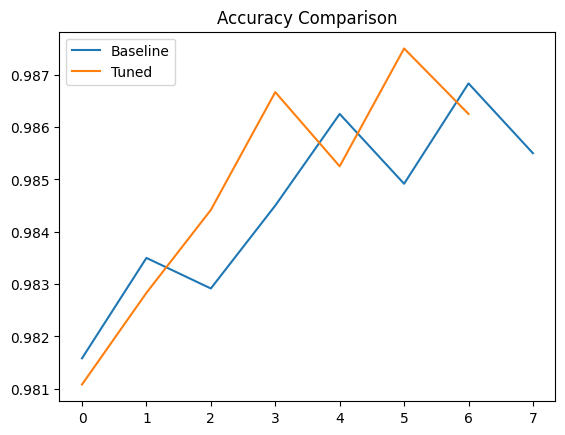

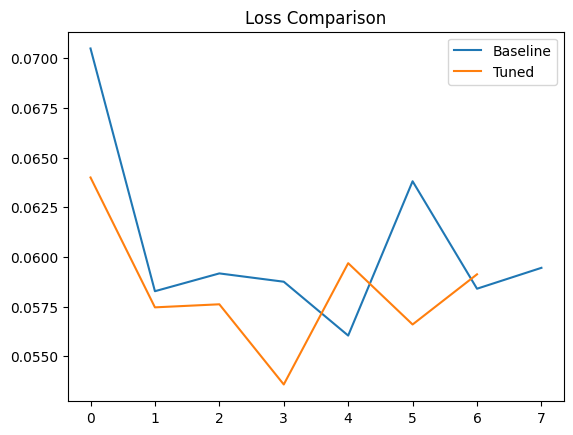

Best Units: 512
Best LR: 0.001
Baseline Acc: 0.9868333339691162
Tuned Acc: 0.987500011920929


In [9]:
# PLOTS
plt.figure()
plt.plot(baseline_history.history['val_accuracy'], label='Baseline')
plt.plot(best_history.history['val_accuracy'], label='Tuned')
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.plot(baseline_history.history['val_loss'], label='Baseline')
plt.plot(best_history.history['val_loss'], label='Tuned')
plt.legend()
plt.title("Loss Comparison")
plt.show()

# RESULTS
print("Best Units:", best_hp.get('units'))
print("Best LR:", best_hp.get('learning_rate'))
print("Baseline Acc:", max(baseline_history.history['val_accuracy']))
print("Tuned Acc:", max(best_history.history['val_accuracy']))